## N23
Implement the gradient descent algorithm with fixed step size.


In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [63]:
def gradient(func, x, h=1e-5):

    x = np.array(x, dtype=float)
    grad = np.zeros_like(x)
    
    for i in range(len(x)):
        x_plus = x.copy()
        x_minus = x.copy()
        x_plus[i] += h
        x_minus[i] -= h
        grad[i] = (func(x_plus) - func(x_minus)) / (2 * h)

    #grad = 2*x[0] + 2
    return -grad

def update_point(current_point, direction, step_size):
    return current_point + step_size * direction

In [64]:
def gradient_descent(func, initial_point, step_size=0.1, max_iter=1000000, tol=1e-6):
    point = initial_point.copy()
    history = [func(point)]
    history_point = [point]
    
    for i in range(max_iter):
        # Compute the descent direction
        # drection = compute_gradient_direction(grad_func, point)
        direction = gradient(func, point)
        # Calculate the next iteration point
        new_point = update_point(point, direction, step_size)
        
        # Check the criterium for stop
        # if np.linalg.norm(new_point - point) < tol:
        #     break
            
        point = new_point
        history.append(func(point))
        history_point.append(point)
        # Check the criterium for stop
        if abs(history[-1] - history[-2]) < tol:
            break
    
    return point, history, history_point

In [65]:
# Example: quadratic function
def quadratic_func(x):
    return x[0]**2 + 2*x[0] + 3


start_point = np.array([6.0])
result, values_history, points_history = gradient_descent(
    quadratic_func, 
    start_point, 
    step_size=0.1
)
print(f"Initial point: {start_point}")
print(f"Result: {result}")
print(f"Function value: {quadratic_func(result):.6f}")
print(f"Interations: {len(values_history)}")


Initial point: [6.]
Result: [-0.99883693]
Function value: 2.000001
Interations: 40


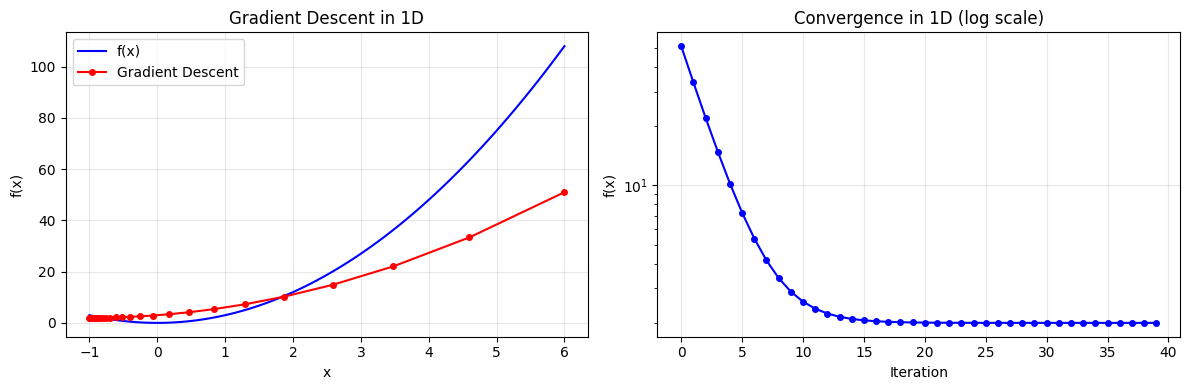

In [66]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Function plot
x_vals = np.linspace(-1, 6, 100)
y_vals = [x**2 + 2*x**2 for x in x_vals]
ax1.plot(x_vals, y_vals, 'b-', label='f(x)')
ax1.plot([x[0] for x in points_history], values_history, 'ro-', markersize=4, label='Gradient Descent')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.set_title('Gradient Descent in 1D')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Convergence plot
ax2.semilogy(range(len(points_history)), values_history, 'b-o', markersize=4)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('f(x)')
ax2.set_title('Convergence in 1D (log scale)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## N25
Generate 30 random symmetric positive definite matrices A of sizes 10 × 10 to 500 ×
500 (generate random matrices B and form A = BTB to get a symmetric matrix that
is very likely positive definite) and a random vector b of the same size. Apply your
algorithm from Exercise 23 to the function q(x) = x
TAx−b
T x from a random starting
point. Calculate the minimizer and test the convergence speed of the algorithm.
Choose the step size optimally.

In [110]:
def generate_random_spd_problem(n, seed=None):
    if seed is not None:
        np.random.seed(seed)
    # Generating random matrix
    B = np.random.randn(n, n)
    A = B.T @ B + 0.1 * np.eye(n)
    # Generating random vector b
    b = np.random.randn(n)
    # Random initial point
    x0 = np.random.randn(n)
    return A, b, x0

In [111]:
def gradient_descent(gradient_func, x0, step_size, max_iter=10000, tol=1e-6):

    x = x0.copy()
    history = []
    grad_norm_history = []

    for i in range(max_iter):
        grad = gradient_func(x)
        grad_norm = np.linalg.norm(grad)
        grad_norm_history.append(grad_norm)

        # Update x
        x = x - step_size * grad

        # Check convergence
        if grad_norm < tol:
            break
    return x, grad_norm_history

In [112]:
def create_quadratic_functions(A, b):
    def q(x):
        return x.T @ A @ x - b.T @ x
    
    def grad_q(x):
        return 2 * A @ x - b
    
    return q, grad_q

In [113]:
def compute_optimal_step_size(A):
        # Calculating the eigenvalues
    eigvals = np.linalg.eigvalsh(A)
    λ_max = np.max(eigvals)
    λ_min = np.min(eigvals)
    return 1.0 / (λ_max + λ_min)

In [123]:
def run_experiment(min_size=10, max_size=500, num_matrices=30, max_iter=100000, tol=1e-6):
    # matrix sizes
    # sizes = np.logspace(
    #     np.log10(min_size), 
    #     np.log10(max_size), 
    #     num_matrices, 
    #     dtype=int
    # )
    sizes = np.linspace(min_size, max_size, num_matrices, dtype=int)
    
    results = []
    
    for i, n in enumerate(sizes):
        print(f"Test {i+1}/{num_matrices}: size = {n}")
        
        # Generating the problem
        A, b, x0 = generate_random_spd_problem(n, seed=i)
        
        # Creating the functions
        q, grad_q = create_quadratic_functions(A, b)
        
        # Compute the optimal step size
        # η_opt, λ_min, λ_max = compute_optimal_step_size(A)
        η_opt = compute_optimal_step_size(A)
        
        eigenvalues = np.linalg.eigvalsh(A)
        λ_max = np.max(eigenvalues)
        λ_min = np.min(eigenvalues)
        L = λ_max * 2  # Lipshitz
        mu = λ_min * 2  
        theoretical_rate = (L - mu) / (L + mu) if L + mu != 0 else 1

        κ = λ_max / λ_min if λ_min > 0 else float('inf')
        # Exact solution
        x_exact = 0.5 * np.linalg.solve(A, b)
        
        # Start of grad desc
        start_time = time.time()
        x_opt, f_history = gradient_descent(grad_q, x0, step_size=η_opt,
            max_iter=max_iter,
            tol=tol
        )
        elapsed_time = time.time() - start_time
        
        # Calculating the errors
        initial_error = np.linalg.norm(x0 - x_exact)
        final_error = np.linalg.norm(x_opt - x_exact)
        grad_norm_final = np.linalg.norm(grad_q(x_opt))
        
        initial_value = q(x0)
        final_value = q(x_opt)
        exact_value = q(x_exact)
        
        # Evaluating the convergence rate 
        practical_rate = None
        if len(f_history) > 10:
            f_errors = np.array(f_history) - exact_value
            mask = f_errors > 0
            if np.sum(mask) > 5:
                log_errors = np.log(f_errors[mask])
                idx = np.arange(len(log_errors))
                coeff = np.polyfit(idx, log_errors, 1)
                practical_rate = np.exp(coeff[0])
        
        result = {
            'size': n,
            'η_opt': η_opt,
            'λ_min': λ_min,
            'λ_max': λ_max,
            'condition_number': κ,
            'iterations': len(f_history),  
            'time': elapsed_time,
            'initial_error': initial_error,
            'final_error': final_error,
            'grad_norm_final': grad_norm_final,
            'initial_value': initial_value,
            'final_value': final_value,
            'exact_value': exact_value,
            'theoretical_rate': theoretical_rate,#(κ - 1) / (κ + 1),
            'practical_rate': practical_rate,
            'f_history': f_history
        }
        
        results.append(result)
        
        print(f"Iterations: {result['iterations']}, Time: {elapsed_time:.3f} с")
        print(f"K: {κ:.2f}")
        print(f"Optimal rate: {η_opt:.6f}")
        print(f"error: {initial_error:.3e} -> {final_error:.3e}")
        print(f"Gradient norm: {grad_norm_final:.3e}")
        print()
    
    return results

In [115]:
NUM_MATRICES = 30
MIN_SIZE = 10
MAX_SIZE = 500
MAX_ITER = 100000
TOL = 1e-4
    # Run the experiment
results = run_experiment(
    min_size=MIN_SIZE,
    max_size=MAX_SIZE,
    num_matrices=NUM_MATRICES,
    max_iter=MAX_ITER,
    tol=TOL
    )
    
    # Статистика
print("\nExperiment statistics:")
iterations = [r['iterations'] for r in results]
times = [r['time'] for r in results]
condition_numbers = [r['condition_number'] for r in results]
    


Test 1/30: size = 10
Iterations: 1952, Time: 0.053 с
K: 300.40
Optimal rate: 0.032998
error: 3.160e+00 -> 1.644e-06
Gradient norm: 9.889e-05

Test 2/30: size = 26
Iterations: 5488, Time: 0.092 с
K: 814.32
Optimal rate: 0.010897
error: 5.030e+00 -> 2.568e-06
Gradient norm: 9.963e-05

Test 3/30: size = 43
Iterations: 12104, Time: 0.244 с
K: 1555.30
Optimal rate: 0.006329
error: 8.023e+00 -> 4.628e-07
Gradient norm: 9.977e-05

Test 4/30: size = 60
Iterations: 18027, Time: 0.371 с
K: 2259.58
Optimal rate: 0.004370
error: 8.044e+00 -> 2.284e-07
Gradient norm: 9.987e-05

Test 5/30: size = 77
Iterations: 16613, Time: 0.330 с
K: 2375.66
Optimal rate: 0.003463
error: 9.672e+00 -> 3.770e-06
Gradient norm: 9.983e-05

Test 6/30: size = 94
Iterations: 24970, Time: 0.578 с
K: 3534.92
Optimal rate: 0.002785
error: 9.726e+00 -> 1.225e-06
Gradient norm: 9.990e-05

Test 7/30: size = 111
Iterations: 33050, Time: 2.852 с
K: 4174.03
Optimal rate: 0.002369
error: 1.170e+01 -> 4.639e-07
Gradient norm: 9.993e

In [116]:
print(f"Average iterations: {np.mean(iterations):.1f}")
print(f"Median iterations: {np.median(iterations):.1f}")
print(f"Min inter: {np.min(iterations)}")
print(f"Max iter: {np.max(iterations)}")
print(f"Average time: {np.mean(times):.3f} с")
print(f"Average condition num: {np.mean(condition_numbers):.2f}")
print(f"Max condition num: {np.max(condition_numbers):.2f}")

Average iterations: 65852.9
Median iterations: 74980.0
Min inter: 1952
Max iter: 100000
Average time: 25.040 с
Average condition num: 9821.67
Max condition num: 20129.59


In [117]:
theoretical_rates = [r['theoretical_rate'] for r in results]
practical_rates = [r['practical_rate'] for r in results if r['practical_rate'] is not None]

avg_theoretical = np.mean(theoretical_rates) if theoretical_rates else 0
avg_practical = np.mean(practical_rates) if practical_rates else 0

print(f"Average theoretical convergence rate: {avg_theoretical:.6f}")
print(f"Average practical convergence rate: {avg_practical:.6f}")

Average theoretical convergence rate: 0.999413
Average practical convergence rate: 0.999898


C:\Users\andre\AppData\Local\Temp\ipykernel_17636\2539402822.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


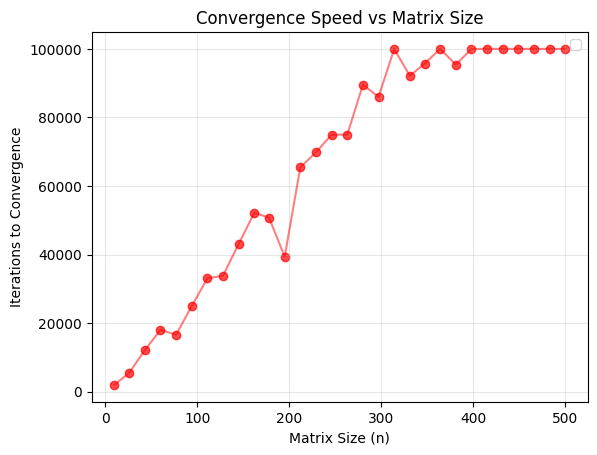

In [118]:
# Plot 2: Iterations needed vs matrix size
#plt.subplot(1, 2, 2)
sizes = [res['size'] for res in results]
iterations_needed = [res['iterations'] for res in results]
plt.scatter(sizes, iterations_needed,color = 'r', alpha=0.7)
plt.plot(sizes, iterations_needed, 'r-', alpha=0.5)

plt.xlabel('Matrix Size (n)')
plt.ylabel('Iterations to Convergence')
plt.title('Convergence Speed vs Matrix Size')
plt.legend()
plt.grid(True, alpha=0.3)

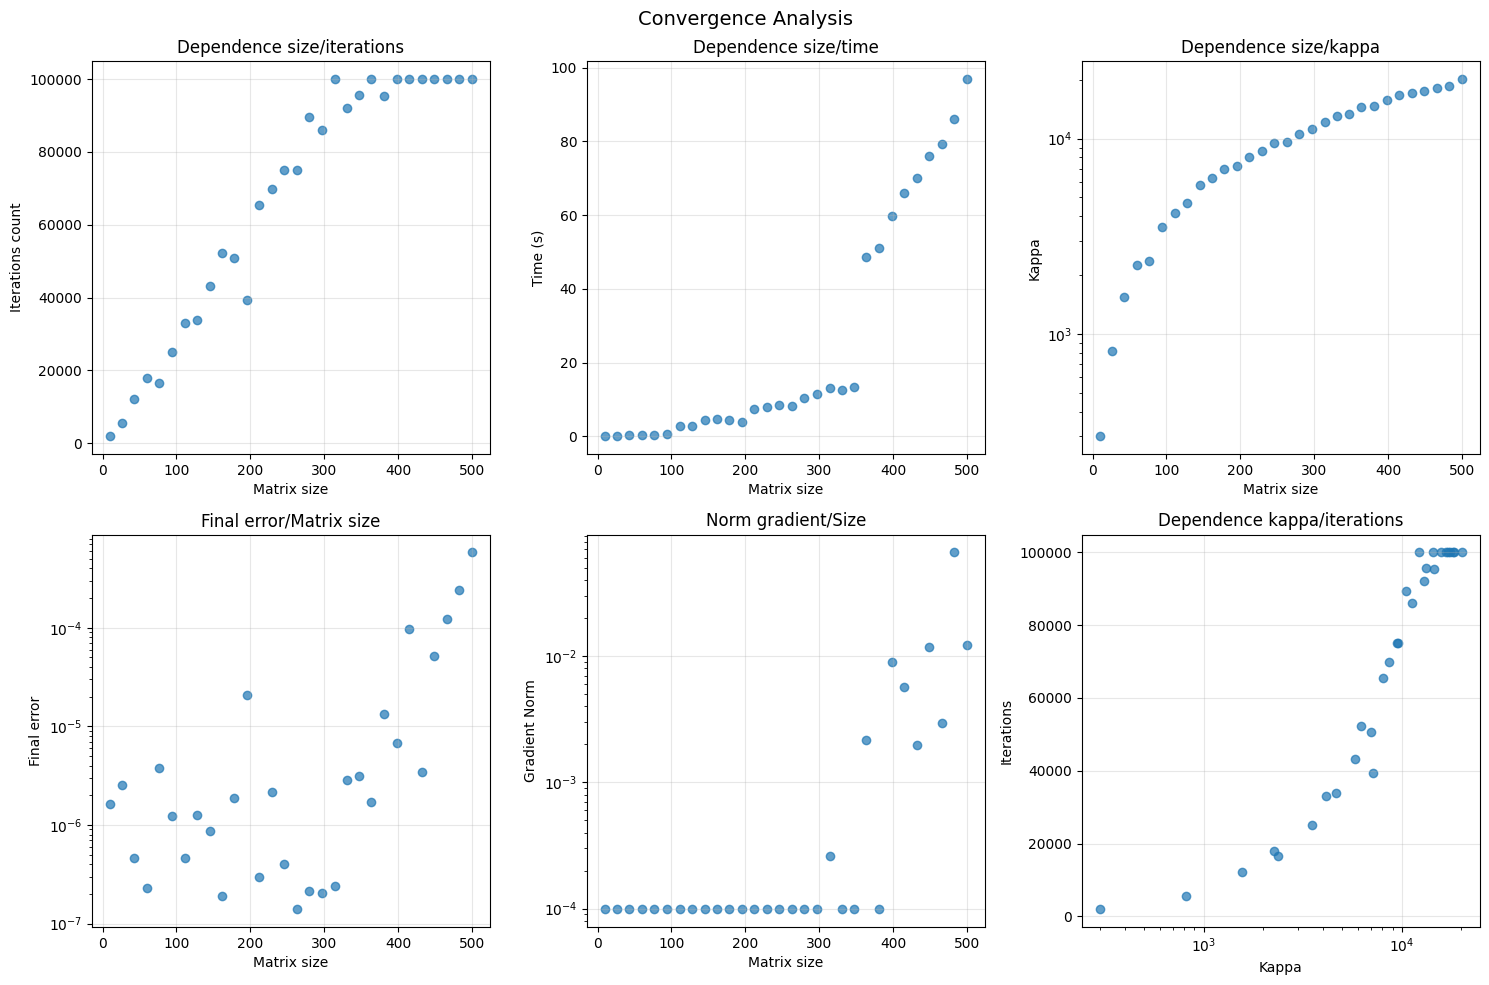

In [119]:
def plot_results(results):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Convergence Analysis', fontsize=14)
    
    sizes = [r['size'] for r in results]
    iterations = [r['iterations'] for r in results]
    times = [r['time'] for r in results]
    condition_numbers = [r['condition_number'] for r in results]
    final_errors = [r['final_error'] for r in results]
    grad_norms = [r['grad_norm_final'] for r in results]
    
    ax = axes[0, 0]
    ax.scatter(sizes, iterations, alpha=0.7)
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Iterations count')
    ax.set_title('Dependence size/iterations')
    ax.grid(True, alpha=0.3)
    
    ax = axes[0, 1]
    ax.scatter(sizes, times, alpha=0.7)
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Time (s)')
    ax.set_title('Dependence size/time')
    ax.grid(True, alpha=0.3)
    
    ax = axes[0, 2]
    ax.scatter(sizes, condition_numbers, alpha=0.7)
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Kappa')
    ax.set_title('Dependence size/kappa')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
  
    ax = axes[1, 0]
    ax.scatter(sizes, final_errors, alpha=0.7)
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Final error')
    ax.set_title('Final error/Matrix size')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, 1]
    ax.scatter(sizes, grad_norms, alpha=0.7)
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Gradient Norm')
    ax.set_title('Norm gradient/Size')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, 2]
    ax.scatter(condition_numbers, iterations, alpha=0.7)
    ax.set_xlabel('Kappa')
    ax.set_ylabel('Iterations')
    ax.set_title('Dependence kappa/iterations')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_results(results)

## N26
Repeat exercise 25 for the function n(x) = sqrt(x^TAx + b^Tx). Compare the results.

In [124]:
def create_function(A, b, epsilon=1e-8):
    def n_func(x):
        under_sqrt = x.T @ A @ x + b.T @ x
        # making sure that under sqaure is positive num
        # return np.sqrt(max(under_sqrt, 0) + epsilon)
        return np.sqrt(under_sqrt + epsilon)
    
    def grad_n_func(x):
        # grad: (2Ax + b) / (2 * sqrt(x^T A x + b^T x))
        under_sqrt = x.T @ A @ x + b.T @ x
        sqrt_term = np.sqrt(max(under_sqrt, 0) + epsilon)
        
        if sqrt_term < 1e-12:  
            return np.zeros_like(x)
        
        return (2 * A @ x + b) / (2 * sqrt_term)
    
    return n_func, grad_n_func

In [121]:
def estimate_optimal_step_size_for_n(x0, A, b):
    """
    Estimate optimal step size for n(x) = sqrt(xᵀAx + bᵀx).
    Since this is not a quadratic, we estimate based on local curvature.
    Returns step size that ensures stability.
    """
    # Compute Hessian at x0 for the function inside the square root
    # f(x) = xᵀAx + bᵀx, Hessian(f) = 2A

    # For n(x) = sqrt(f(x)), the gradient is g = ∇f/(2√f)
    # The Hessian of n is more complex, but we can bound the step size

    # Compute f(x0)
    f_x0 = x0.T @ A @ x0 + b.T @ x0

    if f_x0 <= 0:
        # Use a conservative step size
        return 0.01

    # Get eigenvalues of A
    eigvals = np.linalg.eigvalsh(A)
    λ_max = np.max(eigvals)

    # Estimate Lipschitz constant of gradient of n
    # L ≈ (2λ_max)/(2√f_min) + additional terms
    # We use a conservative estimate
    L_estimate = λ_max / np.sqrt(f_x0) + 0.1

    # Step size should be less than 2/L for convergence
    step_size = 1.0 / L_estimate

    return min(step_size, 0.1)  # Cap at 0.1 for safety

In [125]:
def compute_optimal_step_size(A):
        # Calculating the eigenvalues
    eigvals = np.linalg.eigvalsh(A)
    λ_max = np.max(eigvals)
    λ_min = np.min(eigvals)
    return 1.0 / (λ_max + λ_min)

In [126]:
def run_experiment_n(min_size=10, max_size=500, num_matrices=30, max_iter=1000000,tol=1e-6):
    sizes = np.linspace(min_size, max_size, num_matrices, dtype=int)
    results = []
    for i, n in enumerate(sizes):
        print(f"Test {i+1}/{num_matrices}: size = {n}")
        
        # Generating problem
        A, b, x0 = generate_random_spd_problem(n, seed=i)
        n_func, grad_n_func = create_function(A, b)
        
        eigenvalues = np.linalg.eigvalsh(A)
        λ_min, λ_max = eigenvalues[0], eigenvalues[-1]
        κ = λ_max / λ_min if λ_min > 0 else float('inf')
        
        # Для n(x) эмпирический подбор шага
        # Базовый шаг: 1 / (||A||_2 + ||b||_2)
        norm_A = np.linalg.norm(A, 2)
        norm_b = np.linalg.norm(b, 2)
        η_empirical = 0.1 / (norm_A + norm_b)  # Меньший коэффициент для безопасности
        
        # Пробуем несколько шагов
        # η_candidates = [η_empirical * 0.1, η_empirical * 0.5, η_empirical, 
        #                η_empirical * 2, η_empirical * 5]
        
        # best_η = η_empirical
        # best_iterations = max_iter
        
        # # Быстрый подбор оптимального шага
        # for η_test in η_candidates:
        #     x_test, f_history_test, _ = gradient_descent(
        #         n_func, grad_n_func, x0,
        #         step_size=η_test,
        #         max_iter=200,  # Короткий прогон для теста
        #         tol=tol
        #     )
        #     # Проверяем, что функция не расходится
        #     if len(f_history_test) < 50:  # Слишком быстро сошлось - возможно, шаг слишком большой
        #         continue
        #     # Считаем улучшение за последние 10 итераций
        #     if len(f_history_test) > 20:
        #         improvement = abs(f_history_test[-1] - f_history_test[-10]) / abs(f_history_test[0] - f_history_test[-1])
        #         if improvement < 0.1:  # Хорошее улучшение
        #             iterations_test = len(f_history_test) - 1
        #             if iterations_test < best_iterations:
        #                 best_iterations = iterations_test
        #                 best_η = η_test
        
        # print(f"Select the step size: {best_η:.6e}")
        opt_step_size = compute_optimal_step_size(A)
        
        # Запуск градиентного спуска с выбранным шагом
        start_time = time.time()
        x_opt, f_history, x_history = gradient_descent(
            n_func, grad_n_func, x0,
            step_size=opt_step_size,
            max_iter=max_iter,
            tol=tol
        )
        elapsed_time = time.time() - start_time
        
        # Metrics
        grad_norm_final = np.linalg.norm(grad_n_func(x_opt))
        initial_value = n_func(x0)
        final_value = n_func(x_opt)
        
        # Evaluating convergence rate
        practical_rate = None
        if len(f_history) > 20:
            n_points = len(f_history)
            start_idx = int(0.5 * n_points)
            if start_idx < n_points - 5:
                recent_vals = f_history[start_idx:]
                if len(recent_vals) >= 5:
                    is_monotonic = all(recent_vals[i] <= recent_vals[i-1] for i in range(1, len(recent_vals)))
                    if is_monotonic:
                        log_vals = np.log(np.array(recent_vals) - final_value + 1e-12)
                        idx = np.arange(len(log_vals))
                        coeff = np.polyfit(idx, log_vals, 1)
                        practical_rate = np.exp(coeff[0])
        
        result = {
            'size': n,
            'η': opt_step_size,
            'λ_min': λ_min,
            'λ_max': λ_max,
            'condition_number': κ,
            'iterations': len(f_history) - 1,
            'time': elapsed_time,
            'grad_norm_final': grad_norm_final,
            'initial_value': initial_value,
            'final_value': final_value,
            'practical_rate': practical_rate,
            'f_history': f_history
        }
        
        results.append(result)
        if (i+1 > 45):
            print(f"  Iterations: {result['iterations']}, Time: {elapsed_time:.3f} с")
            print(f"K: {κ:.2f}")
            print(f"Gradient norm: {grad_norm_final:.3e}")
            print(f"Function value: {initial_value:.3e} → {final_value:.3e}")
        
        # Проверка на отрицательное значение под корнем
        under_sqrt_final = x_opt.T @ A @ x_opt + b.T @ x_opt
        if under_sqrt_final < 0:
            print(f"negative val under the sqrt {under_sqrt_final:.3e}")
    
    return results

In [127]:
NUM_MATRICES = 30
MIN_SIZE = 10
MAX_SIZE = 500
MAX_ITER = 100000
TOL = 1e-4
    # Run the experiment
results_26 = run_experiment(
    min_size=MIN_SIZE,
    max_size=MAX_SIZE,
    num_matrices=NUM_MATRICES,
    max_iter=MAX_ITER,
    tol=TOL
    )
    
    # Stats
print("\nExperiment statistics:")
iterations = [r['iterations'] for r in results_26]
times = [r['time'] for r in results_26]
condition_numbers = [r['condition_number'] for r in results_26]
    


Test 1/30: size = 10
Iterations: 1952, Time: 0.043 с
K: 300.40
Optimal rate: 0.032998
error: 3.160e+00 -> 1.644e-06
Gradient norm: 9.889e-05

Test 2/30: size = 26
Iterations: 5488, Time: 0.090 с
K: 814.32
Optimal rate: 0.010897
error: 5.030e+00 -> 2.568e-06
Gradient norm: 9.963e-05

Test 3/30: size = 43
Iterations: 12104, Time: 0.245 с
K: 1555.30
Optimal rate: 0.006329
error: 8.023e+00 -> 4.628e-07
Gradient norm: 9.977e-05

Test 4/30: size = 60
Iterations: 18027, Time: 0.426 с
K: 2259.58
Optimal rate: 0.004370
error: 8.044e+00 -> 2.284e-07
Gradient norm: 9.987e-05

Test 5/30: size = 77
Iterations: 16613, Time: 0.368 с
K: 2375.66
Optimal rate: 0.003463
error: 9.672e+00 -> 3.770e-06
Gradient norm: 9.983e-05

Test 6/30: size = 94
Iterations: 24970, Time: 0.537 с
K: 3534.92
Optimal rate: 0.002785
error: 9.726e+00 -> 1.225e-06
Gradient norm: 9.990e-05

Test 7/30: size = 111
Iterations: 33050, Time: 2.693 с
K: 4174.03
Optimal rate: 0.002369
error: 1.170e+01 -> 4.639e-07
Gradient norm: 9.993e

In [128]:
print(f"Average iterations: {np.mean(iterations):.1f}")
print(f"Median iterations: {np.median(iterations):.1f}")
print(f"Min inter: {np.min(iterations)}")
print(f"Max iter: {np.max(iterations)}")
print(f"Average time: {np.mean(times):.3f} с")
print(f"Average condition num: {np.mean(condition_numbers):.2f}")
print(f"Max condition num: {np.max(condition_numbers):.2f}")

Average iterations: 65852.9
Median iterations: 74980.0
Min inter: 1952
Max iter: 100000
Average time: 29.201 с
Average condition num: 9821.67
Max condition num: 20129.59


In [129]:
theoretical_rates = [r['theoretical_rate'] for r in results_26]
practical_rates = [r['practical_rate'] for r in results_26 if r['practical_rate'] is not None]

avg_theoretical = np.mean(theoretical_rates) if theoretical_rates else 0
avg_practical = np.mean(practical_rates) if practical_rates else 0

print(f"Average theoretical convergence rate: {avg_theoretical:.6f}")
print(f"Average practical convergence rate: {avg_practical:.6f}")

Average theoretical convergence rate: 0.999413
Average practical convergence rate: 0.999898


C:\Users\andre\AppData\Local\Temp\ipykernel_17636\3522938841.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


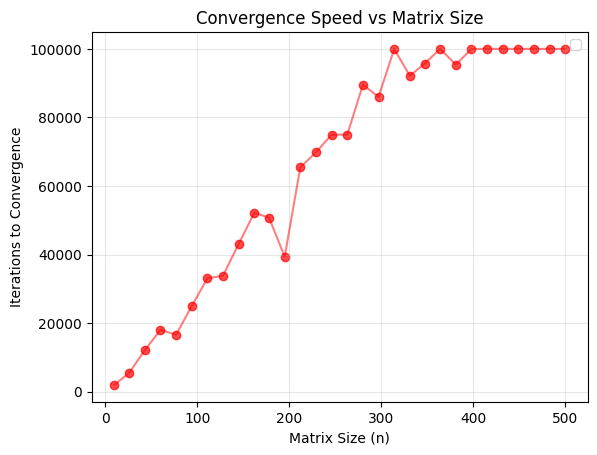

In [130]:
# Plot 2: Iterations needed vs matrix size
#plt.subplot(1, 2, 2)
sizes = [res['size'] for res in results_26]
iterations_needed = [res['iterations'] for res in results_26]
plt.scatter(sizes, iterations_needed,color = 'r', alpha=0.7)
plt.plot(sizes, iterations_needed, 'r-', alpha=0.5)

plt.xlabel('Matrix Size (n)')
plt.ylabel('Iterations to Convergence')
plt.title('Convergence Speed vs Matrix Size')
plt.legend()
plt.grid(True, alpha=0.3)

In [131]:
def plot_comparison_results(results_q, results_n):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Compare grad descent q(x) and n(x)', fontsize=14)
    
    sizes = [r['size'] for r in results_q]
    iterations_q = [r['iterations'] for r in results_q]
    iterations_n = [r['iterations'] for r in results_n]
    times_q = [r['time'] for r in results_q]
    times_n = [r['time'] for r in results_n]
    condition_numbers = [r['condition_number'] for r in results_q]
    
    ax = axes[0, 0]
    ax.scatter(sizes, iterations_q, alpha=0.7, label='q(x)', color='blue')
    ax.scatter(sizes, iterations_n, alpha=0.7, label='n(x)', color='red')
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Iterations')
    ax.set_title('Iterations compare')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[0, 1]
    ax.scatter(sizes, times_q, alpha=0.7, label='q(x)', color='blue')
    ax.scatter(sizes, times_n, alpha=0.7, label='n(x)', color='red')
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Time (s)')
    ax.set_title('Compare time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[0, 2]
    iteration_ratios = [n/q for n, q in zip(iterations_n, iterations_q)]
    ax.scatter(sizes, iteration_ratios, alpha=0.7, color='green')
    ax.axhline(y=1, color='r', linestyle='--', alpha=0.5)
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Iterarions proportion n(x)/q(x)')
    ax.set_title('Iterations proportion')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, 0]
    ax.scatter(condition_numbers, iterations_q, alpha=0.7, color='blue')
    ax.set_xlabel('Kappa')
    ax.set_ylabel('Iterations q(x)')
    ax.set_title('q(x): Iterarions/kappa')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, 1]
    ax.scatter(condition_numbers, iterations_n, alpha=0.7, color='red')
    ax.set_xlabel('Kappa')
    ax.set_ylabel('Iterations n(x)')
    ax.set_title('n(x): Iterarions/kappa')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    
    # ax = axes[1, 2]
    # η_ratios = [r_n['η']/r_q['η'] for r_n, r_q in zip(results_n, results_q)]
    # ax.scatter(sizes, η_ratios, alpha=0.7, color='purple')
    # ax.axhline(y=1, color='r', linestyle='--', alpha=0.5)
    # ax.set_xlabel('Matrix size')
    # ax.set_ylabel('Proportion steps η_n/η_q')
    # ax.set_title('Compare step sizes')
    # ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # if len(results_q) > 5:
    #     idx = 5  
    #     fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
    #     # Сходимость q(x)
    #     ax = axes[0]
    #     f_history_q = results_q[idx]['f_history']
    #     iterations_q = range(len(f_history_q))
    #     ax.semilogy(iterations_q, f_history_q, 'b-', linewidth=2)
    #     ax.set_xlabel('Итерация')
    #     ax.set_ylabel('Значение q(x)')
    #     ax.set_title(f'Сходимость q(x), размер={results_q[idx]["size"]}')
    #     ax.grid(True, alpha=0.3)
        
    #     # Сходимость n(x)
    #     ax = axes[1]
    #     f_history_n = results_n[idx]['f_history']
    #     iterations_n = range(len(f_history_n))
    #     ax.semilogy(iterations_n, f_history_n, 'r-', linewidth=2)
    #     ax.set_xlabel('Итерация')
    #     ax.set_ylabel('Значение n(x)')
    #     ax.set_title(f'Сходимость n(x), размер={results_n[idx]["size"]}')
    #     ax.grid(True, alpha=0.3)
        
    #     plt.tight_layout()
    #     plt.show()

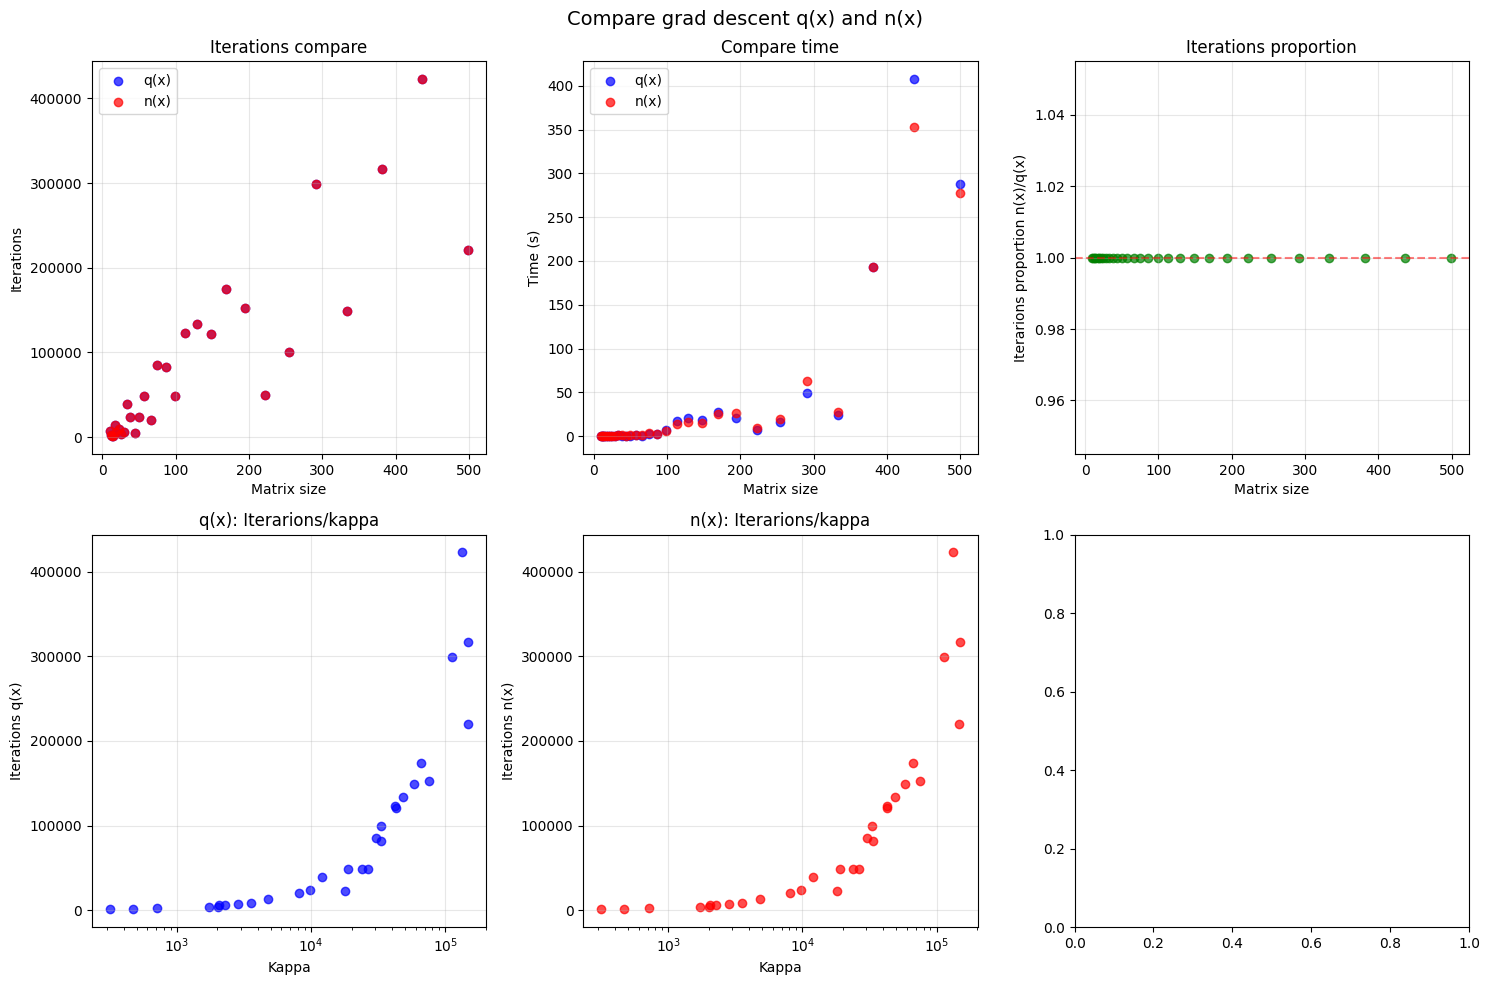

In [25]:
plot_comparison_results(results, results_26)

## N28

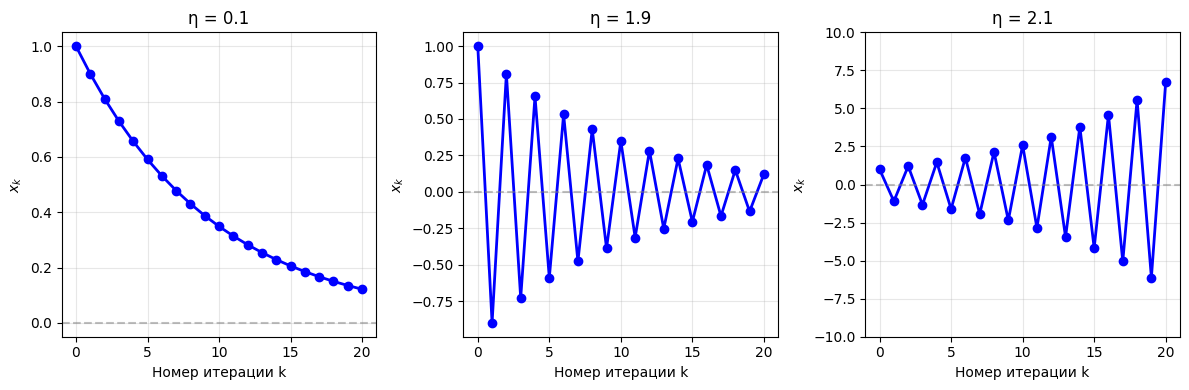

In [132]:
import numpy as np
import matplotlib.pyplot as plt

# Начальные параметры
x0 = 1
k_max = 20
etas = [0.1, 1.9, 2.1]

# Создание графиков
plt.figure(figsize=(12, 4))

for i, eta in enumerate(etas, 1):
    plt.subplot(1, 3, i)
    
    # Вычисление последовательности
    k = np.arange(k_max + 1)
    x = x0 * (1 - eta) ** k
    
    # Построение графика
    plt.plot(k, x, 'bo-', linewidth=2, markersize=6)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.title(f'η = {eta}')
    plt.xlabel('Номер итерации k')
    plt.ylabel('$x_k$')
    plt.grid(True, alpha=0.3)
    
    # Установка пределов для лучшей визуализации
    if eta == 2.1:
        plt.ylim(-10, 10)  # Для расходящегося случая

plt.tight_layout()
plt.show()